# Phase 7 — Explainability and Advanced Model Evaluation

This notebook analyses the frozen final obesity-risk classification model
selected during Phase 6.

The final test set is not used for model selection or hyperparameter tuning.

Phase 7 covers:

1. Final-model verification
2. Global feature importance and SHAP
3. Local prediction explanations
4. Ordinal error analysis
5. BMI feature ablation
6. Subgroup performance analysis

In [1]:
from pathlib import Path
import json
import sys

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
)

RANDOM_STATE = 42

print("scikit-learn:", sklearn.__version__)

scikit-learn: 1.8.0


In [2]:
current_path = Path.cwd().resolve()
PROJECT_ROOT = current_path

while not (
    PROJECT_ROOT / "src" / "preprocessing.py"
).exists():

    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError(
            "Could not locate project root"
        )

    PROJECT_ROOT = PROJECT_ROOT.parent

print("Project root:", PROJECT_ROOT)

Project root: C:\Users\User\OneDrive\Desktop\Obesity-Risk-Intelligence-System


In [3]:
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )

In [4]:
from src.preprocessing import (
    NOMINAL_FEATURES,
    NUMERICAL_FEATURES,
    ORDINAL_CATEGORY_ORDERS,
    ORDINAL_FEATURES,
    PREDICTIVE_FEATURES,
    build_preprocessor,
)

print("Predictive features:", len(PREDICTIVE_FEATURES))
print(PREDICTIVE_FEATURES)

Predictive features: 16
['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'CAEC', 'CALC', 'Gender', 'family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC', 'MTRANS']


In [5]:
DATASET_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "obesity.csv"
)

FINAL_MODEL_PATH = (
    PROJECT_ROOT
    / "models"
    / "obesity_risk_pipeline.joblib"
)

MODEL_METADATA_PATH = (
    PROJECT_ROOT
    / "models"
    / "model_metadata.json"
)

REPORT_DIRECTORY = (
    PROJECT_ROOT
    / "reports"
    / "generated"
)

FIGURE_DIRECTORY = (
    PROJECT_ROOT
    / "reports"
    / "figures"
)

REPORT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

print("Dataset exists:", DATASET_PATH.exists())
print("Model exists:", FINAL_MODEL_PATH.exists())
print("Metadata exists:", MODEL_METADATA_PATH.exists())

Dataset exists: True
Model exists: True
Metadata exists: True


In [6]:
with open(
    MODEL_METADATA_PATH,
    "r",
    encoding="utf-8",
) as file:
    model_metadata = json.load(file)

saved_sklearn_version = (
    model_metadata["scikit_learn_version"]
)

current_sklearn_version = (
    sklearn.__version__
)

print(
    "Current scikit-learn:",
    current_sklearn_version,
)

print(
    "Saved model scikit-learn:",
    saved_sklearn_version,
)

assert (
    current_sklearn_version
    == saved_sklearn_version
), (
    "scikit-learn version mismatch. "
    f"Current={current_sklearn_version}, "
    f"Saved={saved_sklearn_version}"
)

print("Environment version verified")

Current scikit-learn: 1.8.0
Saved model scikit-learn: 1.8.0
Environment version verified


In [7]:
final_model = joblib.load(
    FINAL_MODEL_PATH
)

print(
    "Loaded model:",
    type(final_model).__name__,
)

assert isinstance(
    final_model,
    Pipeline,
)

print(final_model.named_steps.keys())

Loaded model: Pipeline
dict_keys(['preprocessor', 'classifier'])


In [8]:
final_preprocessor = (
    final_model.named_steps[
        "preprocessor"
    ]
)

final_classifier = (
    final_model.named_steps[
        "classifier"
    ]
)

transformed_feature_names = (
    final_preprocessor
    .get_feature_names_out()
)

model_classes = list(
    final_classifier.classes_
)

print(
    "Preprocessor:",
    type(final_preprocessor).__name__,
)

print(
    "Classifier:",
    type(final_classifier).__name__,
)

print(
    "Raw features:",
    len(PREDICTIVE_FEATURES),
)

print(
    "Transformed features:",
    len(transformed_feature_names),
)

print(
    "Classes:",
    len(model_classes),
)

Preprocessor: ColumnTransformer
Classifier: GradientBoostingClassifier
Raw features: 16
Transformed features: 25
Classes: 7


In [9]:
assert len(PREDICTIVE_FEATURES) == 16
assert len(transformed_feature_names) == 25
assert len(model_classes) == 7

assert (
    list(PREDICTIVE_FEATURES)
    == model_metadata[
        "predictive_features"
    ]
)

assert (
    set(model_classes)
    == set(
        model_metadata[
            "target_classes"
        ]
    )
)

print(
    "Model configuration verified"
)

Model configuration verified


In [10]:
dataset = pd.read_csv(
    DATASET_PATH
)

print("Dataset shape:", dataset.shape)

dataset.head()

Dataset shape: (20758, 18)


,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


In [11]:
TARGET_COLUMN = "NObeyesdad"

X = dataset[
    list(PREDICTIVE_FEATURES)
].copy()

y = dataset[
    TARGET_COLUMN
].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20758, 16)
y shape: (20758,)


In [12]:
X_train, X_temp, y_train, y_temp = (
    train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=RANDOM_STATE,
        stratify=y,
    )
)

(
    X_validation,
    X_test,
    y_validation,
    y_test,
) = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

print(
    "Training:",
    len(X_train),
)

print(
    "Validation:",
    len(X_validation),
)

print(
    "Test:",
    len(X_test),
)

Training: 14530
Validation: 3114
Test: 3114


In [13]:
assert (
    len(
        X_train.index.intersection(
            X_validation.index
        )
    )
    == 0
)

assert (
    len(
        X_train.index.intersection(
            X_test.index
        )
    )
    == 0
)

assert (
    len(
        X_validation.index.intersection(
            X_test.index
        )
    )
    == 0
)

print("Dataset split verified")

Dataset split verified


In [14]:
phase7_test_predictions = (
    final_model.predict(
        X_test
    )
)

phase7_test_probabilities = (
    final_model.predict_proba(
        X_test
    )
)

print(
    "Predictions:",
    phase7_test_predictions.shape,
)

print(
    "Probabilities:",
    phase7_test_probabilities.shape,
)

Predictions: (3114,)
Probabilities: (3114, 7)


In [15]:
phase7_metrics = {
    "Accuracy":
        accuracy_score(
            y_test,
            phase7_test_predictions,
        ),

    "Balanced Accuracy":
        balanced_accuracy_score(
            y_test,
            phase7_test_predictions,
        ),

    "Macro F1":
        f1_score(
            y_test,
            phase7_test_predictions,
            average="macro",
        ),

    "Weighted F1":
        f1_score(
            y_test,
            phase7_test_predictions,
            average="weighted",
        ),
}

phase7_metrics_df = pd.DataFrame(
    phase7_metrics.items(),
    columns=[
        "Metric",
        "Score",
    ],
)

phase7_metrics_df

,Metric,Score
0,Accuracy,0.907514
1,Balanced Accuracy,0.897642
2,Macro F1,0.897328
3,Weighted F1,0.907214


In [16]:
metric_checks = {
    "Accuracy":
        model_metadata[
            "final_test_accuracy"
        ],

    "Balanced Accuracy":
        model_metadata[
            "final_test_balanced_accuracy"
        ],

    "Macro F1":
        model_metadata[
            "final_test_macro_f1"
        ],

    "Weighted F1":
        model_metadata[
            "final_test_weighted_f1"
        ],
}

for metric_name, expected_value in (
    metric_checks.items()
):

    calculated_value = (
        phase7_metrics[
            metric_name
        ]
    )

    assert np.isclose(
        calculated_value,
        expected_value,
        atol=1e-10,
    )

print(
    "Final test metrics match metadata"
)

Final test metrics match metadata


In [17]:
test_analysis_df = (
    X_test.copy()
)

test_analysis_df[
    "True_Class"
] = y_test

test_analysis_df[
    "Predicted_Class"
] = phase7_test_predictions

test_analysis_df[
    "Correct_Prediction"
] = (
    test_analysis_df[
        "True_Class"
    ]
    == test_analysis_df[
        "Predicted_Class"
    ]
)

test_analysis_df[
    "Prediction_Confidence"
] = (
    phase7_test_probabilities.max(
        axis=1
    )
)

test_analysis_df[
    [
        "True_Class",
        "Predicted_Class",
        "Correct_Prediction",
        "Prediction_Confidence",
    ]
].head()

,True_Class,Predicted_Class,Correct_Prediction,Prediction_Confidence
16056,Obesity_Type_III,Obesity_Type_III,True,0.999160
19997,Obesity_Type_II,Obesity_Type_II,True,0.996750
16512,Insufficient_Weight,Normal_Weight,False,0.763893
344,Obesity_Type_I,Obesity_Type_II,False,0.990206
6633,Insufficient_Weight,Insufficient_Weight,True,0.879578


In [18]:
assert len(test_analysis_df) == 3114
assert final_model is not None
assert final_preprocessor is not None
assert final_classifier is not None

print(
    "Validation passed"
)

Validation passed


In [19]:
import shap

required_variables = [
    "final_model",
    "final_preprocessor",
    "final_classifier",
    "transformed_feature_names",
    "model_classes",
    "X_train",
    "X_validation",
    "X_test",
    "y_test",
    "test_analysis_df",
]

missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]

assert not missing_variables, (
    "Checkpoint 1 must be executed first. "
    f"Missing: {missing_variables}"
)

print("SHAP:", shap.__version__)
print(
    "Checkpoint 2 dependencies verified"
)

SHAP: 0.52.0
Checkpoint 2 dependencies verified


c:\Users\User\OneDrive\Desktop\Obesity-Risk-Intelligence-System\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [20]:
tree_feature_importance_df = (
    pd.DataFrame(
        {
            "Transformed_Feature":
                transformed_feature_names,

            "Importance":
                final_classifier
                .feature_importances_,
        }
    )
    .sort_values(
        "Importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

tree_feature_importance_df.head(15)

,Transformed_Feature,Importance
0,numerical__Weight,0.580780
1,numerical__FCVC,0.100567
2,numerical__Height,0.076616
3,nominal__Gender_Male,0.055070
4,nominal__Gender_Female,0.051784
5,numerical__Age,0.039661
6,numerical__TUE,0.025355
7,numerical__CH2O,0.015359
8,numerical__NCP,0.014888
9,ordinal__CALC,0.013725


In [21]:
def get_raw_feature_name(
    transformed_feature_name,
):
    clean_name = (
        transformed_feature_name
        .split("__", 1)[-1]
    )

    for raw_feature in sorted(
        PREDICTIVE_FEATURES,
        key=len,
        reverse=True,
    ):

        if (
            clean_name == raw_feature
            or clean_name.startswith(
                f"{raw_feature}_"
            )
        ):
            return raw_feature

    return clean_name

In [22]:
tree_feature_importance_df[
    "Raw_Feature"
] = (
    tree_feature_importance_df[
        "Transformed_Feature"
    ]
    .apply(
        get_raw_feature_name
    )
)

raw_tree_importance_df = (
    tree_feature_importance_df
    .groupby(
        "Raw_Feature",
        as_index=False,
    )["Importance"]
    .sum()
    .sort_values(
        "Importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

raw_tree_importance_df

,Raw_Feature,Importance
0,Weight,0.580780
1,Gender,0.106854
2,FCVC,0.100567
3,Height,0.076616
4,Age,0.039661
5,TUE,0.025355
6,CH2O,0.015359
7,NCP,0.014888
8,CALC,0.013725
9,CAEC,0.008694


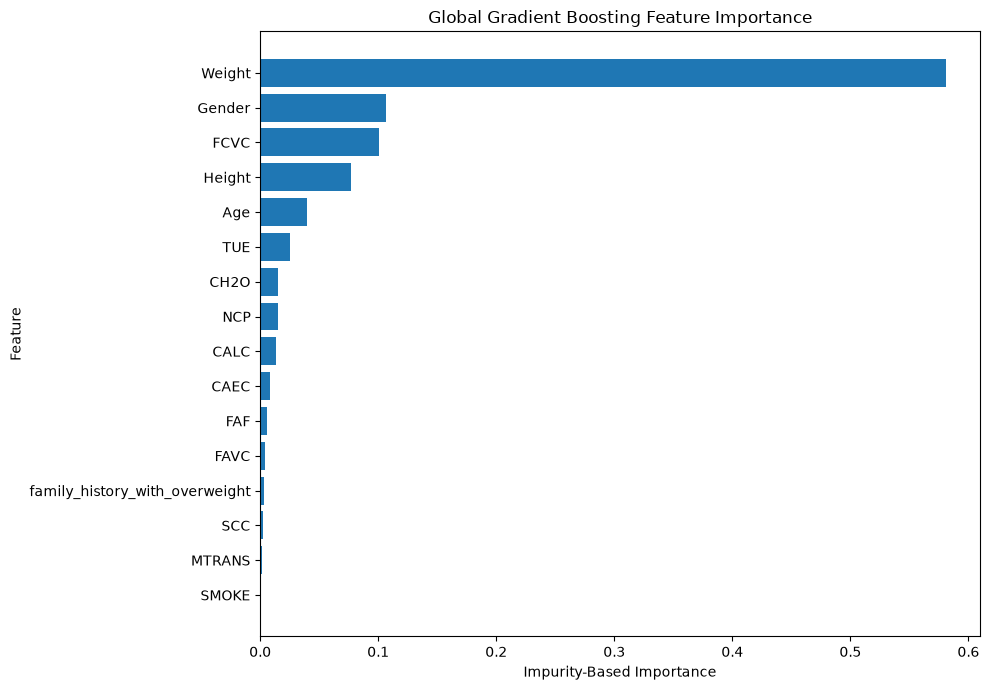

In [23]:
plt.figure(
    figsize=(10, 7)
)

plot_data = (
    raw_tree_importance_df
    .sort_values(
        "Importance",
        ascending=True,
    )
)

plt.barh(
    plot_data["Raw_Feature"],
    plot_data["Importance"],
)

plt.xlabel(
    "Impurity-Based Importance"
)

plt.ylabel("Feature")

plt.title(
    "Global Gradient Boosting "
    "Feature Importance"
)

plt.tight_layout()

tree_figure_path = (
    FIGURE_DIRECTORY
    / "global_tree_feature_importance.png"
)

plt.savefig(
    tree_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [24]:
X_development = pd.concat(
    [
        X_train,
        X_validation,
    ],
    axis=0,
)

SHAP_BACKGROUND_SIZE = 30
SHAP_SAMPLES_PER_CLASS = 8

X_shap_background_raw = (
    X_development.sample(
        n=SHAP_BACKGROUND_SIZE,
        random_state=RANDOM_STATE,
    )
)

shap_sample_indices = []

for class_name in model_classes:

    class_indices = (
        y_test[
            y_test == class_name
        ]
        .sample(
            n=SHAP_SAMPLES_PER_CLASS,
            random_state=RANDOM_STATE,
        )
        .index
        .tolist()
    )

    shap_sample_indices.extend(
        class_indices
    )

X_shap_raw = (
    X_test
    .loc[
        shap_sample_indices
    ]
    .copy()
)

print(
    "Background:",
    len(X_shap_background_raw),
)

print(
    "Explanation sample:",
    len(X_shap_raw),
)

Background: 30
Explanation sample: 56


In [25]:
X_shap_background_transformed = np.asarray(
    final_preprocessor.transform(
        X_shap_background_raw
    )
)

X_shap_transformed = np.asarray(
    final_preprocessor.transform(
        X_shap_raw
    )
)

print(
    "Background shape:",
    X_shap_background_transformed.shape,
)

print(
    "SHAP sample shape:",
    X_shap_transformed.shape,
)

assert (
    X_shap_background_transformed.shape[1]
    == len(transformed_feature_names)
)

assert (
    X_shap_transformed.shape[1]
    == len(transformed_feature_names)
)

print(
    "SHAP transformed data verified"
)

Background shape: (30, 25)
SHAP sample shape: (56, 25)
SHAP transformed data verified


In [26]:
def shap_predict_proba(data):
    return final_classifier.predict_proba(
        np.asarray(data)
    )


shap_explainer = shap.Explainer(
    shap_predict_proba,
    X_shap_background_transformed,
    algorithm="permutation",
    feature_names=list(
        transformed_feature_names
    ),
    output_names=model_classes,
    seed=RANDOM_STATE,
)

print(
    "Explainer:",
    type(shap_explainer).__name__,
)

Explainer: PermutationExplainer


In [27]:
SHAP_MAX_EVALS = (
    2 * len(transformed_feature_names)
    + 1
)

print(
    "Max evaluations:",
    SHAP_MAX_EVALS,
)

shap_values = shap_explainer(
    X_shap_transformed,
    max_evals=SHAP_MAX_EVALS,
)

shap_array = np.asarray(
    shap_values.values
)

print(
    "SHAP shape:",
    shap_array.shape,
)

Max evaluations: 51
SHAP shape: (56, 25, 7)


In [28]:
if (
    shap_array.ndim == 3
    and shap_array.shape[1]
    != len(transformed_feature_names)
    and shap_array.shape[2]
    == len(transformed_feature_names)
):
    shap_array = np.transpose(
        shap_array,
        (0, 2, 1),
    )

assert shap_array.ndim == 3

assert (
    shap_array.shape[1]
    == len(transformed_feature_names)
)

assert (
    shap_array.shape[2]
    == len(model_classes)
)

print(
    "Normalized SHAP shape:",
    shap_array.shape,
)

Normalized SHAP shape: (56, 25, 7)


In [29]:
global_shap_importance = (
    np.abs(shap_array)
    .mean(axis=(0, 2))
)

shap_feature_importance_df = pd.DataFrame(
    {
        "Transformed_Feature":
            transformed_feature_names,

        "SHAP_Importance":
            global_shap_importance,
    }
)

shap_feature_importance_df[
    "Raw_Feature"
] = (
    shap_feature_importance_df[
        "Transformed_Feature"
    ]
    .apply(get_raw_feature_name)
)

raw_shap_importance_df = (
    shap_feature_importance_df
    .groupby(
        "Raw_Feature",
        as_index=False,
    )["SHAP_Importance"]
    .sum()
    .sort_values(
        "SHAP_Importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

raw_shap_importance_df

,Raw_Feature,SHAP_Importance
0,Weight,0.165339
1,FCVC,0.039528
2,Height,0.037055
3,Gender,0.029054
4,Age,0.020786
5,CH2O,0.011997
6,TUE,0.011963
7,MTRANS,0.009090
8,CALC,0.007804
9,family_history_with_overweight,0.007601


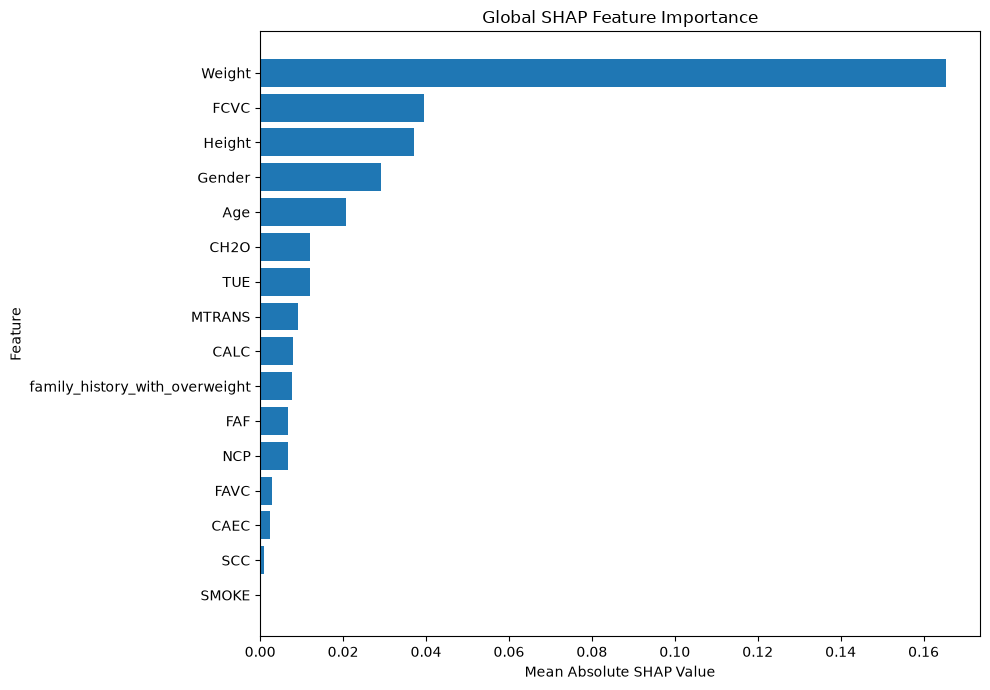

Saved: C:\Users\User\OneDrive\Desktop\Obesity-Risk-Intelligence-System\reports\figures\global_shap_feature_importance.png


In [30]:
plt.figure(
    figsize=(10, 7)
)

plot_data = (
    raw_shap_importance_df
    .sort_values(
        "SHAP_Importance",
        ascending=True,
    )
)

plt.barh(
    plot_data["Raw_Feature"],
    plot_data["SHAP_Importance"],
)

plt.xlabel(
    "Mean Absolute SHAP Value"
)

plt.ylabel("Feature")

plt.title(
    "Global SHAP Feature Importance"
)

plt.tight_layout()

shap_figure_path = (
    FIGURE_DIRECTORY
    / "global_shap_feature_importance.png"
)

plt.savefig(
    shap_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    shap_figure_path,
)

In [31]:
importance_comparison_df = (
    raw_tree_importance_df
    .rename(
        columns={
            "Importance":
                "Tree_Importance"
        }
    )
    .merge(
        raw_shap_importance_df,
        on="Raw_Feature",
        how="inner",
    )
)

importance_comparison_df[
    "Tree_Rank"
] = (
    importance_comparison_df[
        "Tree_Importance"
    ]
    .rank(
        ascending=False,
        method="min",
    )
    .astype(int)
)

importance_comparison_df[
    "SHAP_Rank"
] = (
    importance_comparison_df[
        "SHAP_Importance"
    ]
    .rank(
        ascending=False,
        method="min",
    )
    .astype(int)
)

importance_comparison_df = (
    importance_comparison_df
    .sort_values(
        "SHAP_Rank"
    )
    .reset_index(drop=True)
)

importance_comparison_df

,Raw_Feature,Tree_Importance,SHAP_Importance,Tree_Rank,SHAP_Rank
0,Weight,0.580780,0.165339,1,1
1,FCVC,0.100567,0.039528,3,2
2,Height,0.076616,0.037055,4,3
3,Gender,0.106854,0.029054,2,4
4,Age,0.039661,0.020786,5,5
5,CH2O,0.015359,0.011997,7,6
6,TUE,0.025355,0.011963,6,7
7,MTRANS,0.001880,0.009090,15,8
8,CALC,0.013725,0.007804,9,9
9,family_history_with_overweight,0.003256,0.007601,13,10


In [32]:
tree_report_path = (
    REPORT_DIRECTORY
    / "global_tree_feature_importance.csv"
)

shap_report_path = (
    REPORT_DIRECTORY
    / "global_shap_feature_importance.csv"
)

importance_comparison_path = (
    REPORT_DIRECTORY
    / "global_feature_importance_comparison.csv"
)

raw_tree_importance_df.to_csv(
    tree_report_path,
    index=False,
)

raw_shap_importance_df.to_csv(
    shap_report_path,
    index=False,
)

importance_comparison_df.to_csv(
    importance_comparison_path,
    index=False,
)

print(
    "Checkpoint 2 reports saved"
)

Checkpoint 2 reports saved


In [33]:
assert len(
    raw_tree_importance_df
) == 16

assert len(
    raw_shap_importance_df
) == 16

assert tree_figure_path.exists()
assert shap_figure_path.exists()

assert tree_report_path.exists()
assert shap_report_path.exists()
assert importance_comparison_path.exists()

print(
    "Validation passed"
)

Validation passed


In [34]:
correct_examples = (
    test_analysis_df[
        test_analysis_df[
            "Correct_Prediction"
        ]
    ]
    .sample(
        n=3,
        random_state=RANDOM_STATE,
    )
)

incorrect_examples = (
    test_analysis_df[
        ~test_analysis_df[
            "Correct_Prediction"
        ]
    ]
    .sample(
        n=3,
        random_state=RANDOM_STATE,
    )
)

local_examples = pd.concat(
    [
        correct_examples,
        incorrect_examples,
    ]
)

local_examples[
    [
        "True_Class",
        "Predicted_Class",
        "Correct_Prediction",
        "Prediction_Confidence",
    ]
]

,True_Class,Predicted_Class,Correct_Prediction,Prediction_Confidence
2559,Normal_Weight,Normal_Weight,True,0.715598
2390,Obesity_Type_II,Obesity_Type_II,True,0.979483
1417,Normal_Weight,Normal_Weight,True,0.944338
13312,Obesity_Type_III,Insufficient_Weight,False,0.972829
20265,Normal_Weight,Insufficient_Weight,False,0.989941
19232,Normal_Weight,Insufficient_Weight,False,0.641819


In [35]:
X_local_raw = (
    X_test.loc[
        local_examples.index
    ]
    .copy()
)

X_local_transformed = np.asarray(
    final_preprocessor.transform(
        X_local_raw
    )
)

print(
    "Local transformed shape:",
    X_local_transformed.shape,
)

assert (
    X_local_transformed.shape
    == (6, 25)
)

Local transformed shape: (6, 25)


In [36]:
local_shap_values = shap_explainer(
    X_local_transformed,
    max_evals=SHAP_MAX_EVALS,
)

local_shap_array = np.asarray(
    local_shap_values.values
)

if (
    local_shap_array.ndim == 3
    and local_shap_array.shape[1]
    != len(transformed_feature_names)
    and local_shap_array.shape[2]
    == len(transformed_feature_names)
):
    local_shap_array = np.transpose(
        local_shap_array,
        (0, 2, 1),
    )

assert local_shap_array.ndim == 3

assert (
    local_shap_array.shape[1]
    == len(transformed_feature_names)
)

assert (
    local_shap_array.shape[2]
    == len(model_classes)
)

print(
    "Local SHAP shape:",
    local_shap_array.shape,
)

Local SHAP shape: (6, 25, 7)


In [37]:
local_explanation_rows = []

for position, sample_index in enumerate(
    X_local_raw.index
):

    predicted_class = (
        test_analysis_df.loc[
            sample_index,
            "Predicted_Class",
        ]
    )

    true_class = (
        test_analysis_df.loc[
            sample_index,
            "True_Class",
        ]
    )

    correct_prediction = (
        test_analysis_df.loc[
            sample_index,
            "Correct_Prediction",
        ]
    )

    confidence = (
        test_analysis_df.loc[
            sample_index,
            "Prediction_Confidence",
        ]
    )

    predicted_class_index = (
        model_classes.index(
            predicted_class
        )
    )

    sample_shap_values = (
        local_shap_array[
            position,
            :,
            predicted_class_index,
        ]
    )

    sample_explanation = pd.DataFrame(
        {
            "Transformed_Feature":
                transformed_feature_names,

            "SHAP_Value":
                sample_shap_values,
        }
    )

    sample_explanation[
        "Raw_Feature"
    ] = (
        sample_explanation[
            "Transformed_Feature"
        ]
        .apply(
            get_raw_feature_name
        )
    )

    raw_explanation = (
        sample_explanation
        .groupby(
            "Raw_Feature",
            as_index=False,
        )["SHAP_Value"]
        .sum()
    )

    raw_explanation[
        "Absolute_SHAP"
    ] = (
        raw_explanation[
            "SHAP_Value"
        ]
        .abs()
    )

    raw_explanation = (
        raw_explanation
        .sort_values(
            "Absolute_SHAP",
            ascending=False,
        )
        .head(5)
        .reset_index(drop=True)
    )

    for rank, row in (
        raw_explanation.iterrows()
    ):

        local_explanation_rows.append(
            {
                "Sample_Index":
                    sample_index,

                "True_Class":
                    true_class,

                "Predicted_Class":
                    predicted_class,

                "Correct_Prediction":
                    correct_prediction,

                "Confidence":
                    confidence,

                "Feature":
                    row[
                        "Raw_Feature"
                    ],

                "SHAP_Value":
                    row[
                        "SHAP_Value"
                    ],

                "Absolute_SHAP":
                    row[
                        "Absolute_SHAP"
                    ],

                "Importance_Rank":
                    rank + 1,
            }
        )

local_explanations_df = pd.DataFrame(
    local_explanation_rows
)

local_explanations_df.head(15)

,Sample_Index,True_Class,Predicted_Class,Correct_Prediction,Confidence,Feature,SHAP_Value,Absolute_SHAP,Importance_Rank
0,2559,Normal_Weight,Normal_Weight,True,0.715598,Weight,0.326957,0.326957,1
1,2559,Normal_Weight,Normal_Weight,True,0.715598,Height,0.301552,0.301552,2
2,2559,Normal_Weight,Normal_Weight,True,0.715598,TUE,-0.078218,0.078218,3
3,2559,Normal_Weight,Normal_Weight,True,0.715598,CAEC,-0.071606,0.071606,4
4,2559,Normal_Weight,Normal_Weight,True,0.715598,CH2O,0.044125,0.044125,5
5,2390,Obesity_Type_II,Obesity_Type_II,True,0.979483,Weight,0.436705,0.436705,1
6,2390,Obesity_Type_II,Obesity_Type_II,True,0.979483,Age,0.203401,0.203401,2
7,2390,Obesity_Type_II,Obesity_Type_II,True,0.979483,Gender,0.166097,0.166097,3
8,2390,Obesity_Type_II,Obesity_Type_II,True,0.979483,MTRANS,0.057172,0.057172,4
9,2390,Obesity_Type_II,Obesity_Type_II,True,0.979483,Height,-0.048608,0.048608,5


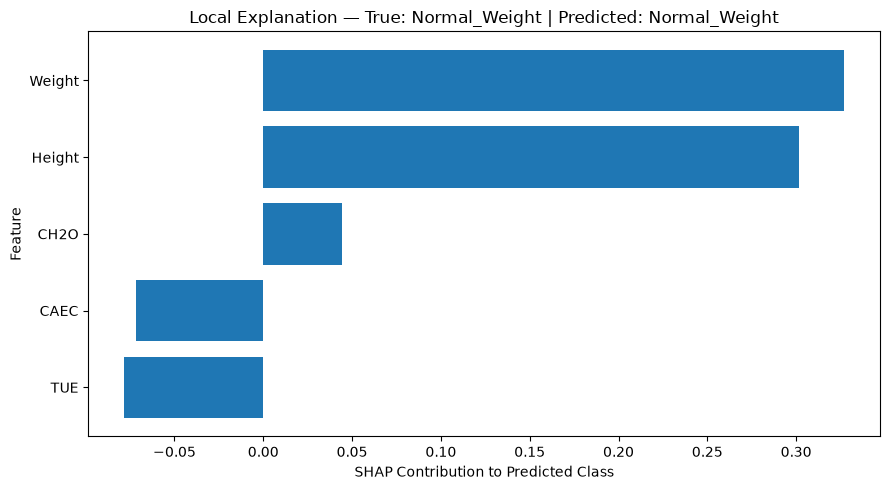

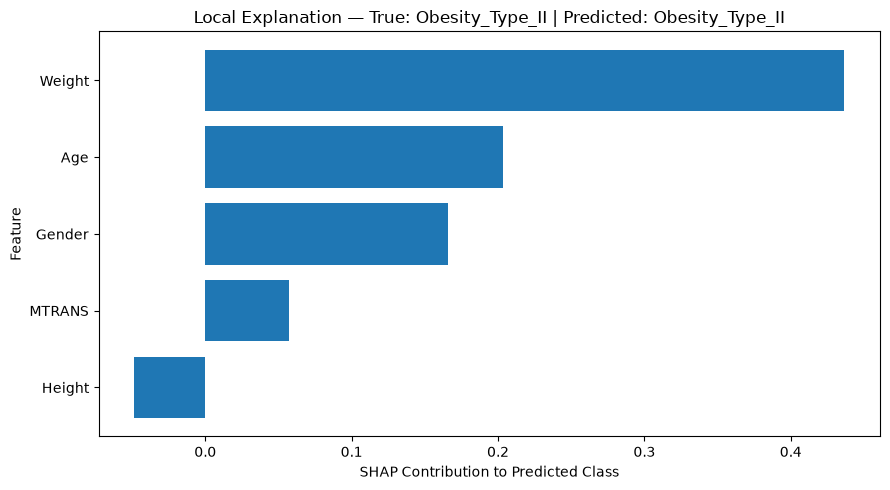

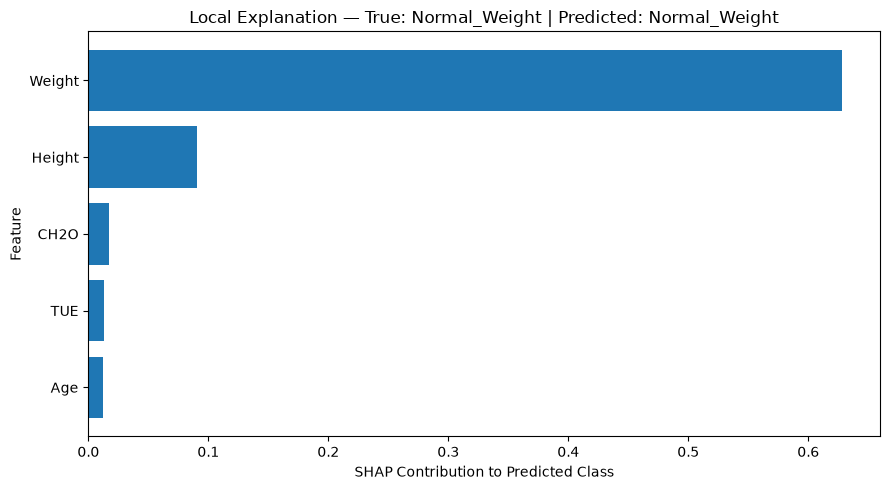

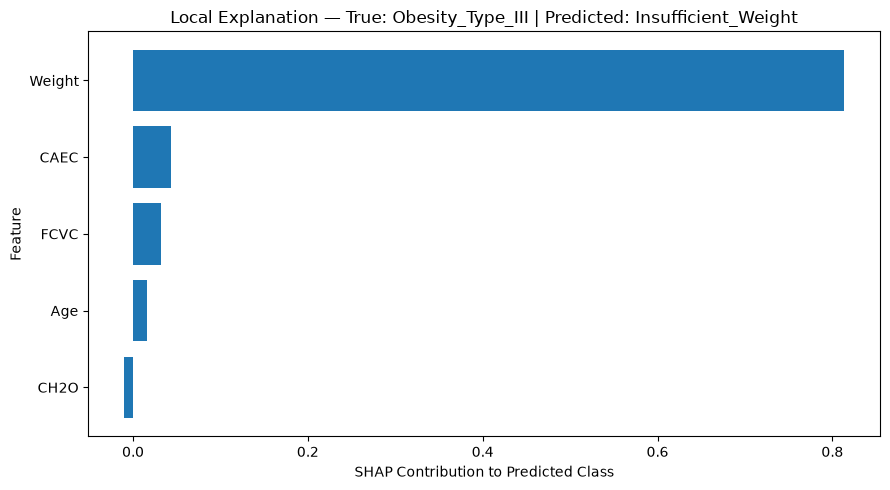

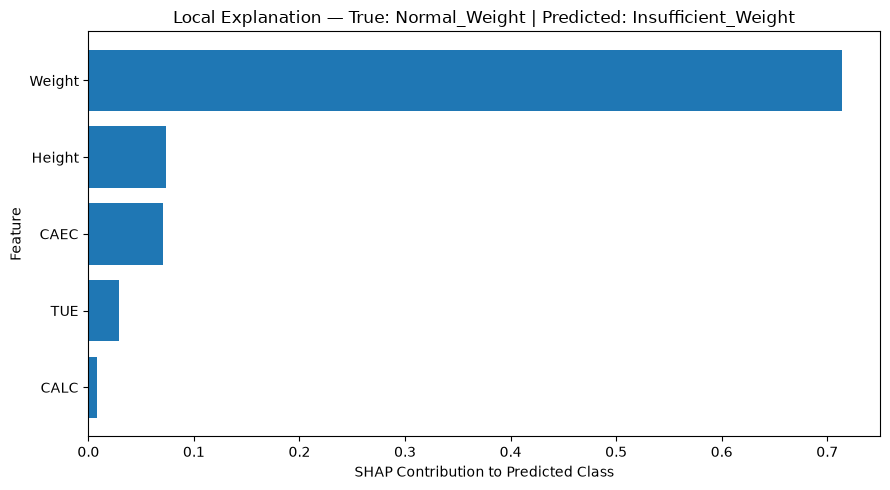

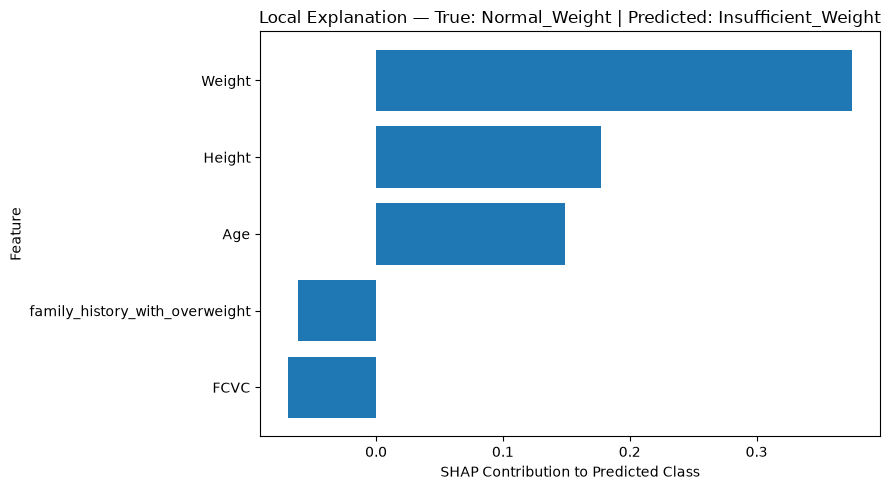

In [38]:
for sample_index in (
    local_explanations_df[
        "Sample_Index"
    ]
    .unique()
):

    sample_data = (
        local_explanations_df[
            local_explanations_df[
                "Sample_Index"
            ]
            == sample_index
        ]
        .sort_values(
            "SHAP_Value"
        )
    )

    predicted_class = (
        sample_data[
            "Predicted_Class"
        ]
        .iloc[0]
    )

    true_class = (
        sample_data[
            "True_Class"
        ]
        .iloc[0]
    )

    plt.figure(
        figsize=(9, 5)
    )

    plt.barh(
        sample_data["Feature"],
        sample_data["SHAP_Value"],
    )

    plt.xlabel(
        "SHAP Contribution "
        "to Predicted Class"
    )

    plt.ylabel(
        "Feature"
    )

    plt.title(
        f"Local Explanation — "
        f"True: {true_class} | "
        f"Predicted: {predicted_class}"
    )

    plt.tight_layout()

    local_figure_path = (
        FIGURE_DIRECTORY
        / (
            f"local_shap_"
            f"{sample_index}.png"
        )
    )

    plt.savefig(
        local_figure_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

In [39]:
local_explanation_path = (
    REPORT_DIRECTORY
    / "local_shap_explanations.csv"
)

local_explanations_df.to_csv(
    local_explanation_path,
    index=False,
)

assert len(
    local_explanations_df
) == 30

assert (
    local_explanation_path.exists()
)

print(
    "Validation passed"
)

Validation passed


In [40]:
OBESITY_CLASS_ORDER = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Overweight_Level_I",
    "Overweight_Level_II",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III",
]

CLASS_TO_LEVEL = {
    class_name: level
    for level, class_name
    in enumerate(
        OBESITY_CLASS_ORDER
    )
}

CLASS_TO_LEVEL

{'Insufficient_Weight': 0,
 'Normal_Weight': 1,
 'Overweight_Level_I': 2,
 'Overweight_Level_II': 3,
 'Obesity_Type_I': 4,
 'Obesity_Type_II': 5,
 'Obesity_Type_III': 6}

In [41]:
ordinal_analysis_df = (
    test_analysis_df.copy()
)

ordinal_analysis_df[
    "True_Level"
] = (
    ordinal_analysis_df[
        "True_Class"
    ]
    .map(CLASS_TO_LEVEL)
)

ordinal_analysis_df[
    "Predicted_Level"
] = (
    ordinal_analysis_df[
        "Predicted_Class"
    ]
    .map(CLASS_TO_LEVEL)
)

assert (
    ordinal_analysis_df[
        "True_Level"
    ]
    .notna()
    .all()
)

assert (
    ordinal_analysis_df[
        "Predicted_Level"
    ]
    .notna()
    .all()
)

ordinal_analysis_df[
    "Ordinal_Distance"
] = (
    ordinal_analysis_df[
        "True_Level"
    ]
    - ordinal_analysis_df[
        "Predicted_Level"
    ]
).abs()

ordinal_analysis_df[
    "Error_Type"
] = np.select(
    [
        ordinal_analysis_df[
            "Ordinal_Distance"
        ] == 0,

        ordinal_analysis_df[
            "Ordinal_Distance"
        ] == 1,
    ],
    [
        "Exact",
        "Adjacent",
    ],
    default="Severe_2_or_More",
)

ordinal_analysis_df[
    [
        "True_Class",
        "Predicted_Class",
        "Ordinal_Distance",
        "Error_Type",
    ]
].head()

,True_Class,Predicted_Class,Ordinal_Distance,Error_Type
16056,Obesity_Type_III,Obesity_Type_III,0,Exact
19997,Obesity_Type_II,Obesity_Type_II,0,Exact
16512,Insufficient_Weight,Normal_Weight,1,Adjacent
344,Obesity_Type_I,Obesity_Type_II,1,Adjacent
6633,Insufficient_Weight,Insufficient_Weight,0,Exact


In [42]:
ordinal_error_summary_df = (
    ordinal_analysis_df[
        "Error_Type"
    ]
    .value_counts()
    .rename_axis(
        "Error_Type"
    )
    .reset_index(
        name="Count"
    )
)

ordinal_error_summary_df[
    "Percentage"
] = (
    ordinal_error_summary_df[
        "Count"
    ]
    / len(
        ordinal_analysis_df
    )
    * 100
)

mean_ordinal_distance = (
    ordinal_analysis_df[
        "Ordinal_Distance"
    ]
    .mean()
)

print(
    "Mean ordinal distance:",
    round(
        mean_ordinal_distance,
        4,
    ),
)

ordinal_error_summary_df

Mean ordinal distance: 0.1092


,Error_Type,Count,Percentage
0,Exact,2826,90.751445
1,Adjacent,246,7.899807
2,Severe_2_or_More,42,1.348748


In [43]:
ordinal_by_class_df = (
    ordinal_analysis_df
    .groupby(
        "True_Class"
    )
    .agg(
        Support=(
            "True_Class",
            "size",
        ),

        Mean_Ordinal_Distance=(
            "Ordinal_Distance",
            "mean",
        ),

        Exact_Rate=(
            "Correct_Prediction",
            "mean",
        ),
    )
    .reset_index()
)

ordinal_by_class_df[
    "Exact_Rate"
] = (
    ordinal_by_class_df[
        "Exact_Rate"
    ]
    * 100
)

ordinal_by_class_df

,True_Class,Support,Mean_Ordinal_Distance,Exact_Rate
0,Insufficient_Weight,378,0.058201,94.179894
1,Normal_Weight,462,0.162338,86.580087
2,Obesity_Type_I,437,0.139588,89.473684
3,Obesity_Type_II,487,0.016427,98.562628
4,Obesity_Type_III,607,0.016474,99.505766
5,Overweight_Level_I,364,0.258242,77.197802
6,Overweight_Level_II,379,0.184697,82.849604


In [44]:
ordinal_summary_path = (
    REPORT_DIRECTORY
    / "ordinal_error_summary.csv"
)

ordinal_by_class_path = (
    REPORT_DIRECTORY
    / "ordinal_error_by_class.csv"
)

ordinal_error_summary_df.to_csv(
    ordinal_summary_path,
    index=False,
)

ordinal_by_class_df.to_csv(
    ordinal_by_class_path,
    index=False,
)

print(
    "Ordinal reports saved"
)

Ordinal reports saved


In [45]:
def add_bmi_feature(
    dataframe,
):
    result = dataframe.copy()

    result["BMI"] = (
        result["Weight"]
        / (
            result["Height"]
            ** 2
        )
    )

    return result

In [46]:
BMI_NUMERICAL_FEATURES = (
    list(NUMERICAL_FEATURES)
    + ["BMI"]
)

def build_bmi_preprocessor():

    numerical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                ),
            ),
            (
                "scaler",
                StandardScaler(),
            ),
        ]
    )

    ordinal_categories = [
        ORDINAL_CATEGORY_ORDERS[
            column
        ]
        for column
        in ORDINAL_FEATURES
    ]

    ordinal_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                ),
            ),
            (
                "encoder",
                OrdinalEncoder(
                    categories=
                        ordinal_categories,

                    handle_unknown=
                        "use_encoded_value",

                    unknown_value=-1,
                ),
            ),
        ]
    )

    nominal_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                ),
            ),
            (
                "encoder",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False,
                ),
            ),
        ]
    )

    return ColumnTransformer(
        transformers=[
            (
                "numerical",
                numerical_pipeline,
                BMI_NUMERICAL_FEATURES,
            ),
            (
                "ordinal",
                ordinal_pipeline,
                ORDINAL_FEATURES,
            ),
            (
                "nominal",
                nominal_pipeline,
                NOMINAL_FEATURES,
            ),
        ],
        remainder="drop",
        verbose_feature_names_out=True,
    )

In [47]:
baseline_ablation_model = Pipeline(
    steps=[
        (
            "preprocessor",
            build_preprocessor(),
        ),
        (
            "classifier",
            clone(
                final_classifier
            ),
        ),
    ]
)

bmi_ablation_model = Pipeline(
    steps=[
        (
            "preprocessor",
            build_bmi_preprocessor(),
        ),
        (
            "classifier",
            clone(
                final_classifier
            ),
        ),
    ]
)

X_train_bmi = add_bmi_feature(
    X_train
)

X_validation_bmi = add_bmi_feature(
    X_validation
)

print(
    "Original feature count:",
    X_train.shape[1],
)

print(
    "BMI experiment feature count:",
    X_train_bmi.shape[1],
)

Original feature count: 16
BMI experiment feature count: 17


In [48]:
baseline_ablation_model.fit(
    X_train,
    y_train,
)

bmi_ablation_model.fit(
    X_train_bmi,
    y_train,
)

print(
    "Ablation models trained"
)

Ablation models trained


In [49]:
baseline_validation_predictions = (
    baseline_ablation_model.predict(
        X_validation
    )
)

bmi_validation_predictions = (
    bmi_ablation_model.predict(
        X_validation_bmi
    )
)


def calculate_ablation_metrics(
    y_true,
    y_pred,
):
    return {
        "Accuracy":
            accuracy_score(
                y_true,
                y_pred,
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred,
            ),

        "Macro_F1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
            ),

        "Weighted_F1":
            f1_score(
                y_true,
                y_pred,
                average="weighted",
            ),
    }


baseline_ablation_metrics = (
    calculate_ablation_metrics(
        y_validation,
        baseline_validation_predictions,
    )
)

bmi_ablation_metrics = (
    calculate_ablation_metrics(
        y_validation,
        bmi_validation_predictions,
    )
)

In [50]:
bmi_ablation_df = pd.DataFrame(
    [
        {
            "Experiment":
                "Original_16_Features",

            **baseline_ablation_metrics,
        },

        {
            "Experiment":
                "Original_Plus_BMI",

            **bmi_ablation_metrics,
        },
    ]
)

baseline_macro_f1 = (
    bmi_ablation_df.loc[
        bmi_ablation_df[
            "Experiment"
        ]
        == "Original_16_Features",
        "Macro_F1",
    ]
    .iloc[0]
)

bmi_macro_f1 = (
    bmi_ablation_df.loc[
        bmi_ablation_df[
            "Experiment"
        ]
        == "Original_Plus_BMI",
        "Macro_F1",
    ]
    .iloc[0]
)

bmi_macro_f1_delta = (
    bmi_macro_f1
    - baseline_macro_f1
)

print(
    "BMI Macro F1 change:",
    round(
        bmi_macro_f1_delta,
        6,
    ),
)

bmi_ablation_df

BMI Macro F1 change: -0.003162


,Experiment,Accuracy,Balanced_Accuracy,Macro_F1,Weighted_F1
0,Original_16_Features,0.907514,0.897894,0.897776,0.907099
1,Original_Plus_BMI,0.904624,0.895014,0.894614,0.904313


In [51]:
bmi_ablation_path = (
    REPORT_DIRECTORY
    / "bmi_ablation_results.csv"
)

bmi_ablation_df.to_csv(
    bmi_ablation_path,
    index=False,
)

assert ordinal_summary_path.exists()
assert ordinal_by_class_path.exists()
assert bmi_ablation_path.exists()

assert (
    len(bmi_ablation_df)
    == 2
)

print(
    "Validation passed"
)

Validation passed


In [52]:
gender_analysis_df = (
    test_analysis_df[
        [
            "Gender",
            "True_Class",
            "Predicted_Class",
        ]
    ]
    .copy()
)

gender_rows = []

for gender_value, group in (
    gender_analysis_df.groupby(
        "Gender"
    )
):

    y_group_true = (
        group["True_Class"]
    )

    y_group_pred = (
        group["Predicted_Class"]
    )

    gender_rows.append(
        {
            "Gender":
                gender_value,

            "Support":
                len(group),

            "Accuracy":
                accuracy_score(
                    y_group_true,
                    y_group_pred,
                ),

            "Balanced_Accuracy":
                balanced_accuracy_score(
                    y_group_true,
                    y_group_pred,
                ),

            "Macro_F1":
                f1_score(
                    y_group_true,
                    y_group_pred,
                    labels=model_classes,
                    average="macro",
                    zero_division=0,
                ),

            "Weighted_F1":
                f1_score(
                    y_group_true,
                    y_group_pred,
                    average="weighted",
                    zero_division=0,
                ),
        }
    )

gender_performance_df = (
    pd.DataFrame(
        gender_rows
    )
)

gender_performance_df

,Gender,Support,Accuracy,Balanced_Accuracy,Macro_F1,Weighted_F1
0,Female,1573,0.910998,0.746858,0.744944,0.910352
1,Male,1541,0.903958,0.890543,0.763548,0.903787


In [53]:
gender_class_distribution_df = (
    pd.crosstab(
        test_analysis_df[
            "Gender"
        ],
        test_analysis_df[
            "True_Class"
        ],
    )
    .reset_index()
)

gender_class_distribution_df

True_Class,Gender,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
0,Female,245,249,192,1,607,164,115
1,Male,133,213,245,486,0,200,264


In [54]:
gender_gap_summary_df = pd.DataFrame(
    [
        {
            "Metric":
                "Accuracy_Gap",

            "Gap":
                gender_performance_df[
                    "Accuracy"
                ].max()
                - gender_performance_df[
                    "Accuracy"
                ].min(),
        },

        {
            "Metric":
                "Macro_F1_Gap",

            "Gap":
                gender_performance_df[
                    "Macro_F1"
                ].max()
                - gender_performance_df[
                    "Macro_F1"
                ].min(),
        },

        {
            "Metric":
                "Balanced_Accuracy_Gap",

            "Gap":
                gender_performance_df[
                    "Balanced_Accuracy"
                ].max()
                - gender_performance_df[
                    "Balanced_Accuracy"
                ].min(),
        },
    ]
)

gender_gap_summary_df

,Metric,Gap
0,Accuracy_Gap,0.007040
1,Macro_F1_Gap,0.018604
2,Balanced_Accuracy_Gap,0.143685


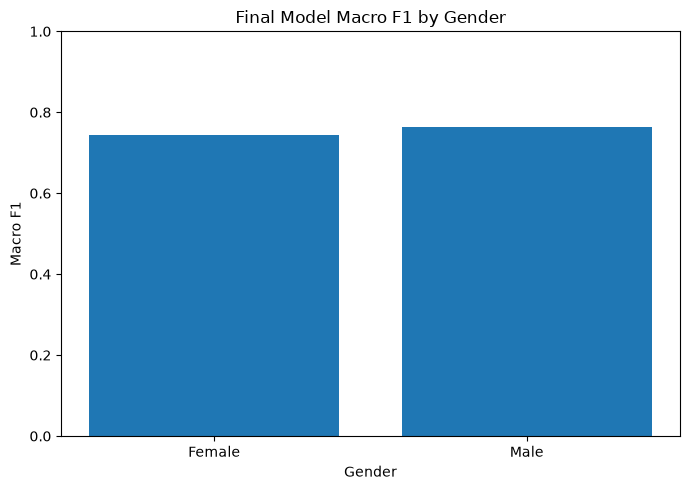

Saved: C:\Users\User\OneDrive\Desktop\Obesity-Risk-Intelligence-System\reports\figures\gender_subgroup_macro_f1.png


In [55]:
plt.figure(
    figsize=(7, 5)
)

plt.bar(
    gender_performance_df[
        "Gender"
    ],
    gender_performance_df[
        "Macro_F1"
    ],
)

plt.ylabel(
    "Macro F1"
)

plt.xlabel(
    "Gender"
)

plt.title(
    "Final Model Macro F1 by Gender"
)

plt.ylim(
    0,
    1,
)

plt.tight_layout()

gender_figure_path = (
    FIGURE_DIRECTORY
    / "gender_subgroup_macro_f1.png"
)

plt.savefig(
    gender_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    gender_figure_path,
)

In [56]:
gender_performance_path = (
    REPORT_DIRECTORY
    / "gender_subgroup_performance.csv"
)

gender_distribution_path = (
    REPORT_DIRECTORY
    / "gender_class_distribution.csv"
)

gender_gap_path = (
    REPORT_DIRECTORY
    / "gender_subgroup_gap_summary.csv"
)

gender_performance_df.to_csv(
    gender_performance_path,
    index=False,
)

gender_class_distribution_df.to_csv(
    gender_distribution_path,
    index=False,
)

gender_gap_summary_df.to_csv(
    gender_gap_path,
    index=False,
)

print(
    "Subgroup reports saved"
)

Subgroup reports saved


In [57]:
top_tree_features = (
    raw_tree_importance_df[
        "Raw_Feature"
    ]
    .head(5)
    .tolist()
)

top_shap_features = (
    raw_shap_importance_df[
        "Raw_Feature"
    ]
    .head(5)
    .tolist()
)

exact_rate = (
    (
        ordinal_analysis_df[
            "Ordinal_Distance"
        ] == 0
    )
    .mean()
)

adjacent_rate = (
    (
        ordinal_analysis_df[
            "Ordinal_Distance"
        ] == 1
    )
    .mean()
)

severe_error_rate = (
    (
        ordinal_analysis_df[
            "Ordinal_Distance"
        ] >= 2
    )
    .mean()
)

gender_macro_f1_gap = (
    gender_performance_df[
        "Macro_F1"
    ].max()
    - gender_performance_df[
        "Macro_F1"
    ].min()
)

phase7_summary = {
    "model":
        model_metadata[
            "selected_candidate"
        ],

    "test_macro_f1":
        float(
            phase7_metrics[
                "Macro F1"
            ]
        ),

    "top_tree_features":
        top_tree_features,

    "top_shap_features":
        top_shap_features,

    "mean_ordinal_distance":
        float(
            mean_ordinal_distance
        ),

    "exact_prediction_rate":
        float(
            exact_rate
        ),

    "adjacent_error_rate":
        float(
            adjacent_rate
        ),

    "severe_error_rate":
        float(
            severe_error_rate
        ),

    "bmi_macro_f1_delta":
        float(
            bmi_macro_f1_delta
        ),

    "gender_macro_f1_gap":
        float(
            gender_macro_f1_gap
        ),
}

phase7_summary

{'model': 'Tuned Gradient Boosting',
 'test_macro_f1': 0.8973281823370796,
 'top_tree_features': ['Weight', 'Gender', 'FCVC', 'Height', 'Age'],
 'top_shap_features': ['Weight', 'FCVC', 'Height', 'Gender', 'Age'],
 'mean_ordinal_distance': 0.10918432883750803,
 'exact_prediction_rate': 0.9075144508670521,
 'adjacent_error_rate': 0.0789980732177264,
 'severe_error_rate': 0.01348747591522158,
 'bmi_macro_f1_delta': -0.003162276706815015,
 'gender_macro_f1_gap': 0.018603861671558697}

In [58]:
phase7_summary_path = (
    REPORT_DIRECTORY
    / "phase7_summary.json"
)

with open(
    phase7_summary_path,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        phase7_summary,
        file,
        indent=4,
    )

print(
    "Saved:",
    phase7_summary_path,
)

Saved: C:\Users\User\OneDrive\Desktop\Obesity-Risk-Intelligence-System\reports\generated\phase7_summary.json


In [60]:
required_reports = [
    tree_report_path,
    shap_report_path,
    importance_comparison_path,
    local_explanation_path,
    ordinal_summary_path,
    ordinal_by_class_path,
    bmi_ablation_path,
    gender_performance_path,
    gender_distribution_path,
    gender_gap_path,
    phase7_summary_path,
]

required_figures = [
    tree_figure_path,
    shap_figure_path,
    gender_figure_path,
]

for file_path in (
    required_reports
    + required_figures
):
    assert file_path.exists(), (
        f"Missing output: {file_path}"
    )

assert len(
    raw_tree_importance_df
) == 16

assert len(
    raw_shap_importance_df
) == 16

assert len(
    test_analysis_df
) == 3114

assert len(
    model_classes
) == 7

assert len(
    local_explanations_df
) == 30